### 線型代数

In [1]:
using LinearAlgebra
using Random

Random.seed!(1234)  

const TOL = 1e-10

1.0e-10

In [4]:
A = [3.0 1.0 0.0;
     1.0 2.0 1.0;
     0.0 1.0 1.0]

x = [1.0, 2.0, 3.0]

println("A*x = ", A*x)
println("A' (転置) = ", A')
println("A^2 = ", A^2)
println("dot(x, x) (内積) = ", dot(x, x))
println("norm(x) (ノルム) = ", norm(x))
println("opnorm(A, 2)（行列ノルム） = ", opnorm(A, 2))
println("det(A)（行列式） = ", det(A))
println("inv(A)（逆行列） = ", inv(A))
println("tr(A)（トレース） = ", tr(A))
println("eigen(A)（固有値・固有ベクトル） = ", eigen(A))
println("svd(A)（特異値分解） = ", svd(A))
println("cholesky(A)（コレスキー分解） = ", cholesky(A))
println("qr(A)（QR分解） = ", qr(A))
println("lu(A)（LU分解） = ", lu(A))
println("rank(A)（ランク） = ", rank(A, TOL))
println("nullspace(A)（ヌルスペース） = ", nullspace(A, TOL))
println("orthogonalize columns of A（直交化） = ", qr(A).Q)

A*x = [5.0, 8.0, 5.0]
A' (転置) = [3.0 1.0 0.0; 1.0 2.0 1.0; 0.0 1.0 1.0]
A^2 = [10.0 5.0 1.0; 5.0 6.0 3.0; 1.0 3.0 2.0]
dot(x, x) (内積) = 14.0
norm(x) (ノルム) = 3.7416573867739413
opnorm(A, 2)（行列ノルム） = 3.732050807568877
det(A)（行列式） = 2.0
inv(A)（逆行列） = [0.49999999999999994 -0.4999999999999999 0.49999999999999994; -0.5 1.5 -1.5; 0.5 -1.5 2.5]
tr(A)（トレース） = 6.0
eigen(A)（固有値・固有ベクトル） = Eigen{Float64, Float64, Matrix{Float64}, Vector{Float64}}([0.2679491924311268, 2.0, 3.732050807568877], [0.2113248654051879 0.5773502691896253 0.7886751345948131; -0.5773502691896267 -0.5773502691896252 0.5773502691896256; 0.7886751345948121 -0.5773502691896268 0.21132486540518702])
svd(A)（特異値分解） = SVD{Float64, Float64, Matrix{Float64}, Vector{Float64}}([-0.7886751345948132 0.5773502691896256 0.2113248654051872; -0.5773502691896257 -0.577350269189626 -0.5773502691896258; -0.21132486540518697 -0.577350269189626 0.788675134594813], [3.732050807568877, 1.9999999999999987, 0.26794919243112275], [-0.788675134594813 -0

In [ ]:
# 下三角行列、上三角行列の和・積・逆行列もまた下三角行列、上三角行列になる

W = [1.0 2.0 3.0 ;
     0.0 1.0 0.0 ;
     0.0 0.0 1.0 ;]

println("W+W = ", W + W)
println("W*W = ", W * W)
println("W^-1 = ", inv(W))

W+W = [2.0 4.0 6.0; 0.0 2.0 0.0; 0.0 0.0 2.0]
W*W = [1.0 4.0 6.0; 0.0 1.0 0.0; 0.0 0.0 1.0]
W^-1 = [1.0 -2.0 -3.0; 0.0 1.0 0.0; 0.0 0.0 1.0]


#### 核とランクの視覚的理解

rank(A) = 2
dim ker(A) = 1
ker direction v = [-0.7071067811865475, 0.0, 0.7071067811865475]


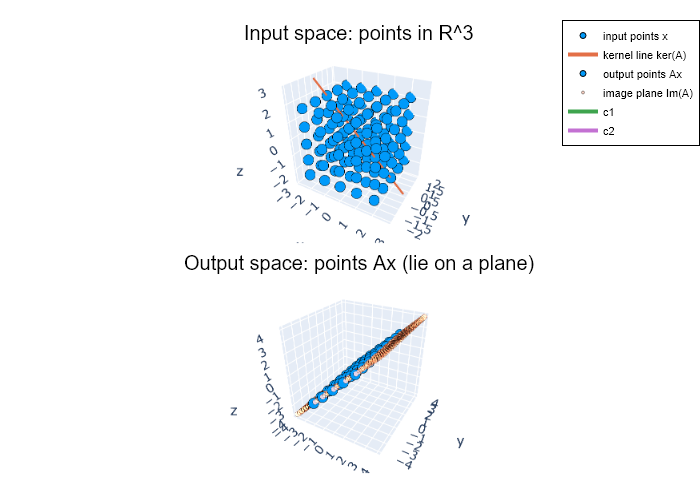

In [14]:
using LinearAlgebra
using Plots
plotlyjs()  # 3Dをマウスで回転できる

# -----------------------
# 行列 A（あなたの例）
# -----------------------
A = [0.0 -1.0  0.0;
    -1.0  0.0 -1.0;
     0.0 -1.0  0.0]

# 核（nullspace）: A v = 0 の解空間の基底（列ベクトル）
K = nullspace(A)     # 3×k（ここではk=1のはず）
v = K[:, 1]          # 核の方向ベクトル

# 像（column space）: A が作り出す出力の空間 = 列空間
# rank(A) 本の独立な列をとれば、その張る平面が像
# ここでは A の列は c1=[0,-1,0], c2=[-1,0,-1], c3=[0,-1,0] で
# 独立なのは2本（rank=2）。c1 と c2 を使う
c1 = A[:, 1]
c2 = A[:, 2]

println("rank(A) = ", rank(A))
println("dim ker(A) = ", size(K,2))
println("ker direction v = ", v)

# -----------------------
# 1) 入力空間の点を作る（立方体グリッド）
# -----------------------
grid = -2:1:2
X = Float64[]
Y = Float64[]
Z = Float64[]
for x in grid, y in grid, z in grid
    push!(X, x); push!(Y, y); push!(Z, z)
end

# -----------------------
# 2) それらを A で写した出力点（Ax）
# -----------------------
Xp = Float64[]
Yp = Float64[]
Zp = Float64[]
for i in eachindex(X)
    u = [X[i], Y[i], Z[i]]
    w = A*u
    push!(Xp, w[1]); push!(Yp, w[2]); push!(Zp, w[3])
end

# -----------------------
# 3) 核の直線（入力側）を描く： t*v
# -----------------------
t = range(-4, 4, length=200)
kx = [ti*v[1] for ti in t]
ky = [ti*v[2] for ti in t]
kz = [ti*v[3] for ti in t]

# -----------------------
# 4) 像（出力側）の平面を描く： s*c1 + u*c2
# -----------------------
sgrid = range(-4, 4, length=30)
ugrid = range(-4, 4, length=30)

PX = Float64[]; PY = Float64[]; PZ = Float64[]
for s in sgrid, u in ugrid
    p = s*c1 + u*c2
    push!(PX, p[1]); push!(PY, p[2]); push!(PZ, p[3])
end

# -----------------------
# 5) プロット（入力空間と出力空間を並べて表示）
# -----------------------

p_in = scatter3d(X, Y, Z, ms=3, label="input points x",
                 title="Input space: points in R^3")
plot!(p_in, kx, ky, kz, lw=4, label="kernel line ker(A)")

p_out = scatter3d(Xp, Yp, Zp, ms=3, label="output points Ax",
                  title="Output space: points Ax (lie on a plane)")
scatter3d!(p_out, PX, PY, PZ, ms=1.5, alpha=0.35, label="image plane Im(A)")
# 平面の方向ベクトルも描く（c1,c2）
plot!(p_out, [0,c1[1]], [0,c1[2]], [0,c1[3]], lw=4, label="c1")
plot!(p_out, [0,c2[1]], [0,c2[2]], [0,c2[3]], lw=4, label="c2")

plot(p_in, p_out, layout=(2,1), size=(700,1000))


まず前提として、行列 $A$ は「写像（操作）」のこと。今回の場合、3x3 行列なので形式的には$$A:\mathbb{R}^3 \to \mathbb{R}^3$$となる。つまり入力も出力も"座標としては"3次元である。ただし重要なのは、出力が $\mathbb{R}^3$ のどこにでも散らばるとは限らず、ある平面や直線に押しつぶされることがある、という点。そこに「核（カーネル）」「像」「ランク」が入ってくる。  
1. 左の図（入力空間）の意味：**カーネルは操作 $A$ が見えない方向である**  
左の図は、入力の空間 $\mathbb{R}^3$（格子点で可視化した点群）を描いて、その中にカーネルの方向をオレンジの直線で重ねたものである。  
カーネルは定義で$$ker(A) = \{ x \in \mathbb{R}^3 | Ax = 0 \}$$であるので、つまり**入力のうち $A$ をかけるとゼロに潰れてしまう（出力がゼロになる）ベクトル全体**。  
カーネルが直線で描けるのは、今回の $ker(A)$ が1次元だからで、一般にはカーネルは平面（2次元）だったり、$\mathbb{R}^3$ 全体（3次元）だったりする。  
次の等式が重要：$$v \in ker(A) \Rightarrow Av = 0$$これより任意の $t$ に対して$$A(tv) = tAv = 0$$つまりカーネル方向（今回でいえば直線）上の点は全部ゼロに写る。さらに任意の入力 $x$ とカーネル方向 $v$ について$$A(x + tv) = Ax + tAv = Ax$$が成り立つ。これは、カーネル方向にどれだけ入力を動かしても、出力は全く変わらないという意味。したがって左図に描かれているカーネル直線は $\underline{ A が区別できない自由度（写像後に情報として失われる方向）}$ を表している。

2. 右の図（出力空間）の意味：  
右の図は、同じ入力点群を $A$ で写した点群 $\{Ax\}$ を出力空間（座標としては $\mathbb{R}^3$ ）に描いたもの。ここで驚きなのは、3x3行列なのに点群が3次元に広がらずに"ある平面上"にしか現れない。これがランクが2であることの視覚化である。  
この"ある平面上"のことを像といい、定義は $$Im(A) = \{Ax \in \mathbb{R}^3 | x \in \mathbb{R}^3 \}$$ つまり**Aが作り出せる出力全体**のことである。ここで押さえるべき事実は、像とは列ベクトルの張る部分空間であり、右図の平面はまさに独立な列ベクトル2本（ランク2）が張る平面ということである。  
  
ランクは定義的に $$rank(A) = dim(Im(A))$$ で右図で像が平面（2次元）に見えるのは、ランクが2だから。カーネルの次元（nullity）は $$dim(ker(A))$$で、左図でカーネルが直線（1次元）に見えるのは nullity が1だから。また、この2つの間に $$dim(ker(A)) + rank(A) = 3$$ という関係があった。これらのことを一般化すると、  
> **次元定理**：
> $A$ を $m$ 行 $n$ 列の行列とするとき以下が成り立つ。
> $$rank(A) = dim(Im(A)),$$
> $$dim(ker(A)) = n - rank(A)$$
  
今回の例では、$$A = \begin{pmatrix} 0 & -1 & 0 \\ -1 & 0 & -1 \\ 0 & -1 & 0 \end{pmatrix} $$で核は $$ker(A) = span\left\{ \begin{pmatrix} 1 \\ 0 \\ -1 \end{pmatrix} \right\}$$である。なので左図に描かれている直線はこの方向である。一方、列ベクトルは $$c_1 = \begin{pmatrix} 0 \\ -1 \\ 0 \end{pmatrix}, \quad c_2 = \begin{pmatrix} -1 \\ 0 \\ -1 \end{pmatrix}, \quad c_3 = \begin{pmatrix} 0 \\ -1 \\ 0 \end{pmatrix}(=c_1)$$ で独立なのは $c_1,c_2$ の2本なので、像は $$Im(A) = span\{c_1,c_2\}$$という2次元平面になる。これが右図の平面である。  
  
以上をまとめると
> 行列$A$は、入力の自由度のうち核に属する部分を捨てて、残りを像（ランク次元の部分空間）に写している。  
  
- フルランク：情報完全保存
- ランク落ち：一部情報喪失
- ランク0：情報全喪失  
  
- 核＝固有値0の固有空間
- ランク＝非ゼロ固有値の本数
- 像＝非ゼロ固有値方向が張る空間